# PREPARATION

In [10]:
import pandas as pd
import os

data_folder = './datasets/'

# Map 2020's old column names to the modern 2021-2024 names (2020's missing 'Have')
rename_map = {
    'LanguageWorkedWith': 'LanguageHaveWorkedWith',
    'DatabaseWorkedWith': 'DatabaseHaveWorkedWith',
    'PlatformWorkedWith': 'PlatformHaveWorkedWith',
    'WebframeWorkedWith': 'WebframeHaveWorkedWith',
    'MiscTechWorkedWith': 'MiscTechHaveWorkedWith'
}

# Select key columns
target_columns = [
    'MainBranch',
    'DevType',
    'LanguageHaveWorkedWith', 
    'DatabaseHaveWorkedWith', 
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'MiscTechHaveWorkedWith',
    'ToolsTechHaveWorkedWith',
    *rename_map.keys()
]

# Filter key columns
all_years_data = []
for filename in os.listdir(data_folder):
    filepath = os.path.join(data_folder, filename)
    df_year = pd.read_csv(filepath, usecols=lambda c: c in target_columns, low_memory=False)
    df_year = df_year.rename(columns=rename_map)
    all_years_data.append(df_year)

df = pd.concat(all_years_data, ignore_index=True)

print(f"Total rows loaded: {len(df)}")

# Isolate tech columns for baskets creation
tech_columns = [
    'LanguageHaveWorkedWith', 
    'DatabaseHaveWorkedWith', 
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'MiscTechHaveWorkedWith',
    'ToolsTechHaveWorkedWith'
]

for col in tech_columns:
    df[col] = df[col].fillna('') + ';'

# Create a master column of one's entire stack
df['Full_Stack'] = df[tech_columns].sum(axis=1)

# Create & clean transactions
transactions_raw = df['Full_Stack'].str.strip(';').str.split(';')
df['Transaction_Basket'] = [
    [tech.strip() for tech in stack if tech.strip() != ''] 
    for stack in transactions_raw
]

# Filter by profession, removing hobbyists
df = df[df['MainBranch'].str.contains('developer by profession', na=False, case=False)]
df = df[df['Transaction_Basket'].map(len) > 0]
df = df.reset_index(drop=True)

# Check
print(f"Total valid developer transactions: {len(df['Transaction_Basket'])}")
print("\nFirst 3 transactions:")
for i in range(3):
    print(df['Transaction_Basket'].iloc[i])

Total rows loaded: 375789
Total valid developer transactions: 274135

First 3 transactions:
['C#', 'HTML/CSS', 'JavaScript', 'Elasticsearch', 'Microsoft SQL Server', 'Oracle', 'Windows', 'ASP.NET', 'ASP.NET Core', '.NET', '.NET Core']
['JavaScript', 'Swift', 'iOS', 'React Native']
['HTML/CSS', 'Ruby', 'SQL', 'MySQL', 'PostgreSQL', 'Redis', 'SQLite', 'AWS', 'Docker', 'Linux', 'MacOS', 'Windows', 'Ruby on Rails', 'Ansible']


Successfully merged 5 years worth of data into one dataframe, string splitting worked (languages [javascript...], databases [postgreSQL], framework [Laravel...] in a single basket, which apiory could work with)

# DATA ANALYSIS

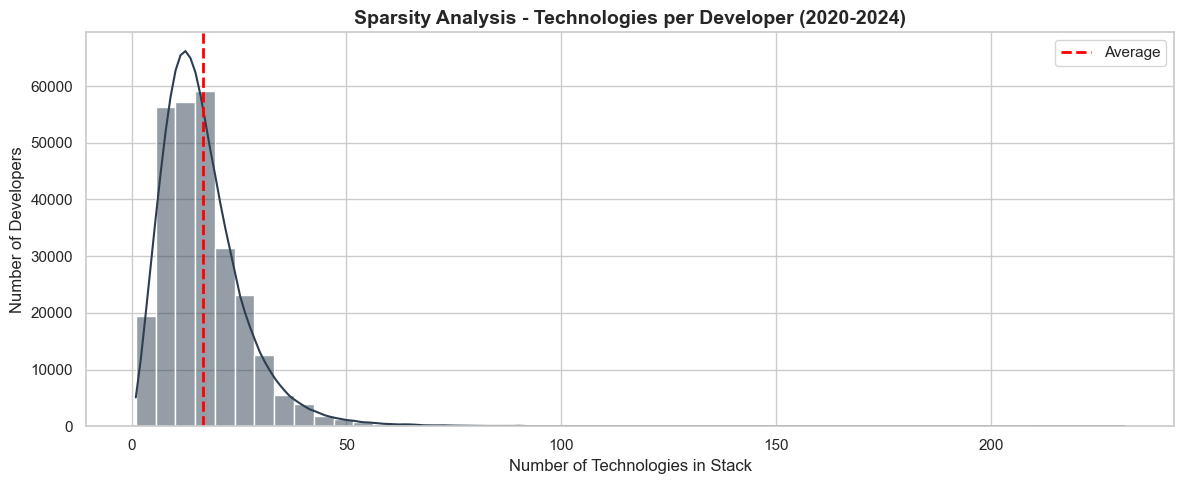

Average stack size: 16.58 technologies per developer


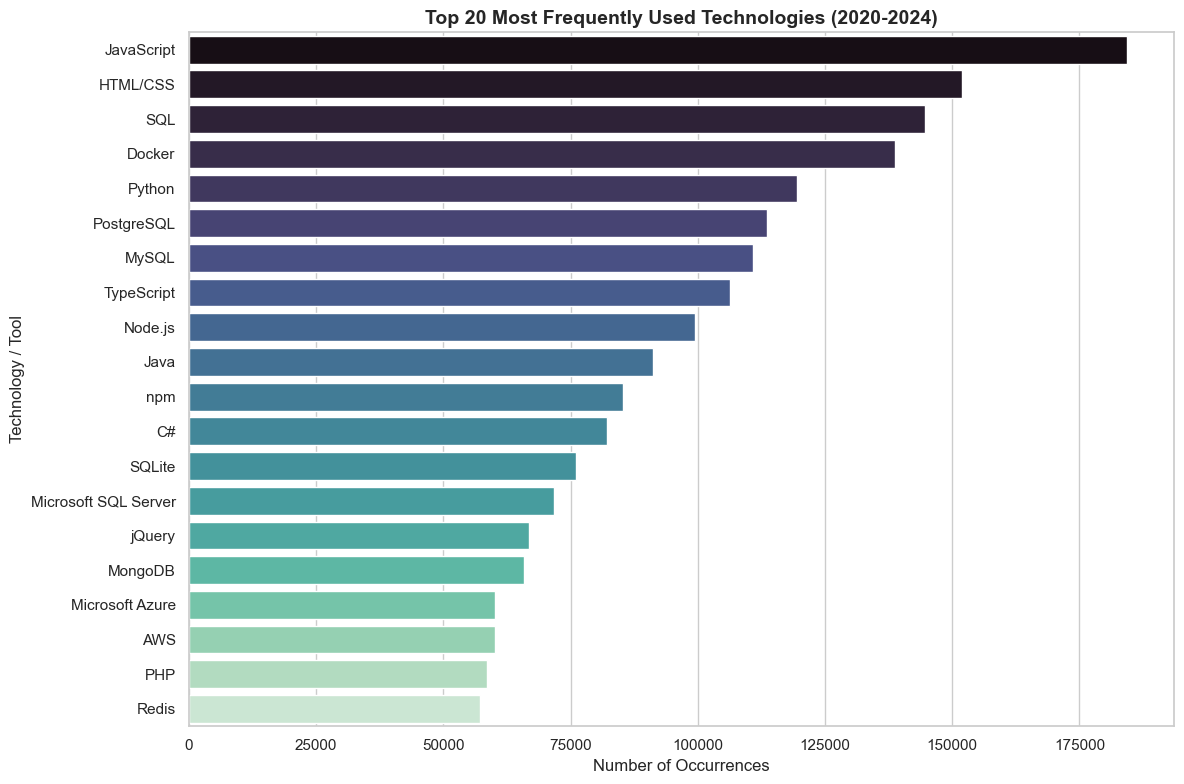

Total unique technologies: 281


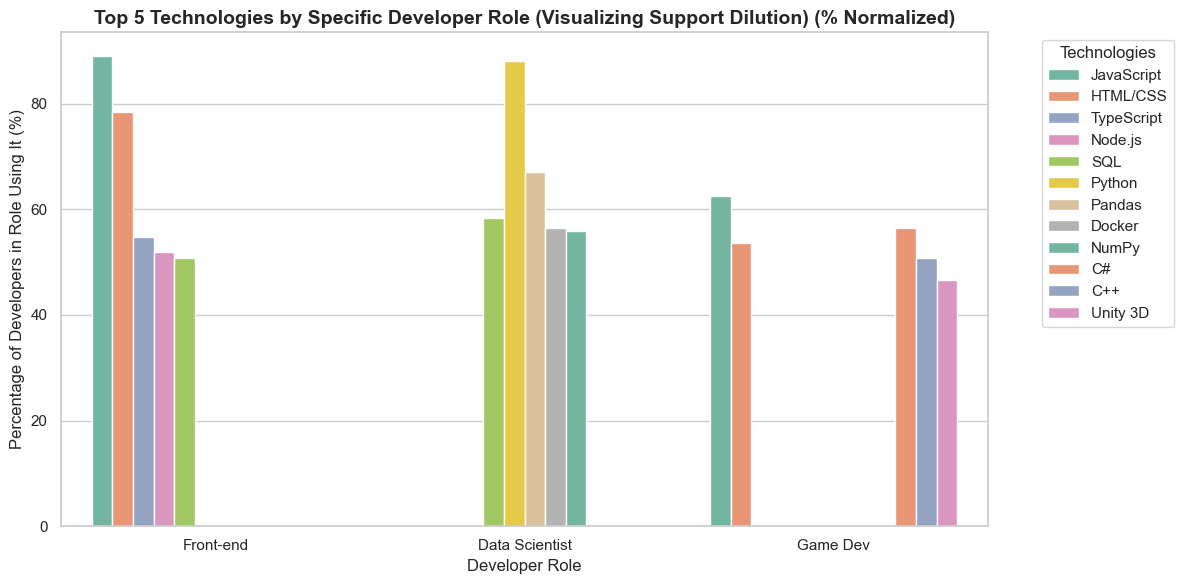

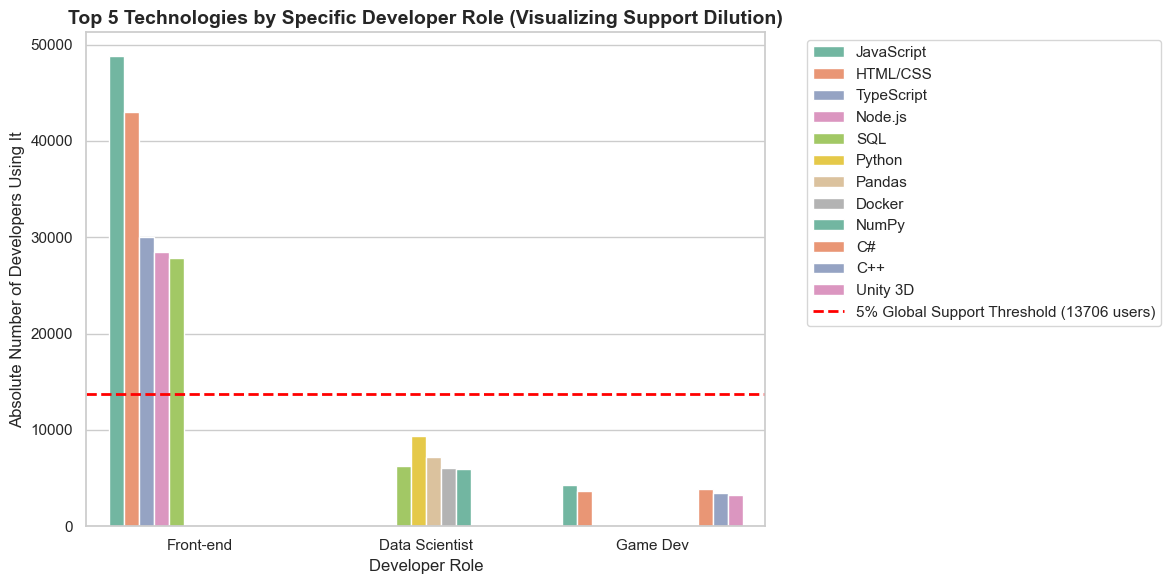

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

transactions = df['Transaction_Basket'].tolist()
sns.set_theme(style="whitegrid")

# ==========================================
# CHART 1: Sparsity Analysis (Stack Sizes)
# Count how many technologies are in each developer's stack
# ==========================================

stack_sizes = [len(transaction) for transaction in transactions]

plt.figure(figsize=(12, 5))
sns.histplot(stack_sizes, bins=50, kde=True, color='#2c3e50')
plt.title('Sparsity Analysis - Technologies per Developer (2020-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Technologies in Stack', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)
plt.axvline(sum(stack_sizes)/len(stack_sizes), color='red', linestyle='dashed', linewidth=2, label='Average')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average stack size: {sum(stack_sizes)/len(stack_sizes):.2f} technologies per developer")

# ==========================================
# CHART 2: Frequency Analysis (Top 20 Tech)
# ==========================================

all_tech = [tech.strip() for transaction in transactions for tech in transaction]

# Count the occurrences of each technology
tech_counts = Counter(all_tech)
top_20 = tech_counts.most_common(20)

# Extract names and frequencies for the chart
tech_names = [x[0] for x in top_20]
tech_freq = [x[1] for x in top_20]

plt.figure(figsize=(12, 8))
sns.barplot(x=tech_freq, y=tech_names, hue=tech_names, palette='mako', legend=False)
plt.title('Top 20 Most Frequently Used Technologies (2020-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Technology / Tool', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Total unique technologies: {len(tech_counts)}")

# ==========================================
# CHART 3: Top Tech by Developer Role (% Normalized)
# ==========================================

roles_to_check = {
    'Front-end': 'front-end',
    'Data Scientist': 'data scientist',
    'Game Dev': 'game or graphics',
}

role_tech_data = []
role_tech_data_norm = []

for role_name, keyword in roles_to_check.items():
    df_role = df[df['DevType'].str.contains(keyword, na=False, case=False)]
    role_transactions = df_role['Transaction_Basket'].tolist()
    role_all_tech = [tech.strip() for transaction in role_transactions for tech in transaction]
    role_top_5 = Counter(role_all_tech).most_common(5)
    
    for tech, count in role_top_5:
        role_tech_data.append({'Role': role_name, 'Technology': tech, 'Raw Count': count})
        percentage = (count / len(df_role)) * 100 
        role_tech_data_norm.append({'Role': role_name, 'Technology': tech, 'Usage (%)': percentage})


df_role_chart = pd.DataFrame(role_tech_data_norm)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_role_chart, x='Role', y='Usage (%)', hue='Technology', palette='Set2')
plt.title('Top 5 Technologies by Specific Developer Role (Visualizing Support Dilution) (% Normalized)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Developers in Role Using It (%)', fontsize=12)
plt.xlabel('Developer Role', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Technologies")
plt.tight_layout()
plt.show()

# ==========================================
# CHART 3 ALTERNATIVE: Top Tech by Developer Role (Absolute)
# ==========================================

df_role_chart = pd.DataFrame(role_tech_data)

# Calculate a hypothetical 5% global threshold to draw a "Danger Line"
global_5_percent = len(df) * 0.05 

plt.figure(figsize=(12, 6))
sns.barplot(data=df_role_chart, x='Role', y='Raw Count', hue='Technology', palette='Set2')
plt.axhline(y=global_5_percent, color='red', linestyle='dashed', linewidth=2, 
            label=f'5% Global Support Threshold ({int(global_5_percent)} users)')

plt.title('Top 5 Technologies by Specific Developer Role (Visualizing Support Dilution)', fontsize=14, fontweight='bold')
plt.ylabel('Absolute Number of Developers Using It', fontsize=12)
plt.xlabel('Developer Role', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Inferences & Methodological Justification:

- Sparsity Analysis (Stack per Developer): The chart demonstrates that the average developer stack consists of only 17 out of approximately 300 unique technologies, indicating a highly sparse transaction matrix. This justifies the selection of the FP-Growth algorithm over the baseline Apriori. By compressing only active tools into an FP-Tree—rather than generating millions of zero-value candidate combinations—FP-Growth effectively bypasses the computational memory bottlenecks associated with this extreme dataset sparsity.

- Technology Frequency: While this chart highlights the most globally popular technologies, it exposes a critical limitation of traditional frequency analysis: production environments rarely rely on a single language. Instead, they require interconnected frameworks and ecosystems that often include niche, specialized tools. Standard "top technology" lists fail to capture these dependencies, a gap this project bridges by using Association Rule Mining to mathematically identify strict architectural co-occurrences rather than mere popularity.

- Technology Adoption by Profession (Normalized vs. Absolute): The normalized percentage chart successfully isolates the foundational pipelines for specific roles (e.g., Python for Data Science). However, viewing the data in absolute numbers reveals a severe statistical imbalance: the sheer volume of web developers mathematically dwarfs other specializations. This introduces the risk of "Support Dilution," where highly coupled but lower-volume tools are erroneously deleted by the algorithm simply because they fail to meet global minimum support thresholds. This stark contrast definitively justifies the dual Macro/Micro methodology. The Macro (global) run successfully identifies universal industry utilities (like Git or Docker), while the Micro (segmented) runs mathematically preserve the rigid, specialized pipelines native to distinct professions.

# DATA MINING

In [30]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# ==========================================
# HELPER FUNCTION: Mine Rules from a DataFrame
# ==========================================
def mine_tech_rules(df_subset, min_support_val=0.05, min_lift_val=1.5):
    """
    Takes a subset of developers, encodes their baskets, 
    runs FP-Growth, and returns the top association rules.
    """
    print(f"Processing {len(df_subset)} developers...")
    
    # 1. Extract the lists of strings
    transactions = df_subset['Transaction_Basket'].tolist()
    
    # 2. One-Hot Encode (True/False matrix required by mlxtend)
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
    
    # 3. Run FP-Growth
    frequent_itemsets = fpgrowth(df_encoded, min_support=min_support_val, use_colnames=True)
    
    # If no frequent itemsets meet the threshold, return empty
    if frequent_itemsets.empty:
        return pd.DataFrame()
        
    # 4. Generate Rules using Lift as the primary metric
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_lift_val)
    
    # 5. Sort by highest Lift (the most rigid dependencies)
    rules = rules.sort_values(by='lift', ascending=False)
    
    return rules

display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']

# ==========================================
# RUN 1: MACRO ANALYSIS (The Global Baseline)
# ==========================================
print("--- MACRO RUN (All Professional Developers) ---")
# Using a 5% support threshold because the population is massive
macro_rules = mine_tech_rules(df, min_support_val=0.05, min_lift_val=1.5)

print(f"Discovered {len(macro_rules)} significant global rules.")
print(macro_rules[display_cols].head(5).to_string(index=False))


# ==========================================
# RUN 2: MICRO ANALYSIS (Segmented by Role)
# ==========================================
print("\n--- MICRO RUN (Front-end Developers Only) ---")
df_frontend = df[df['DevType'].str.contains('front-end', na=False, case=False)]

# We can use a slightly higher support threshold (e.g., 8%) here 
# because the data is already tightly scoped to one specific profession.
micro_rules_fe = mine_tech_rules(df_frontend, min_support_val=0.08, min_lift_val=1.5)

print(f"Discovered {len(micro_rules_fe)} Front-end specific rules.")
print(micro_rules_fe[display_cols].head(5).to_string(index=False))


print("\n--- MICRO RUN (Data Scientists Only) ---")
df_data = df[df['DevType'].str.contains('data scientist', na=False, case=False)]

micro_rules_ds = mine_tech_rules(df_data, min_support_val=0.08, min_lift_val=1.5)

print(f"Discovered {len(micro_rules_ds)} Data Science specific rules.")
print(micro_rules_ds[display_cols].head(5).to_string(index=False))

--- MACRO RUN (All Professional Developers) ---
Processing 274135 developers...
Discovered 35148 significant global rules.
                  antecedents                   consequents  support  confidence      lift
   frozenset({C#, .NET (5+)})     frozenset({ASP.NET CORE}) 0.057114    0.683861 10.178644
    frozenset({ASP.NET CORE})    frozenset({C#, .NET (5+)}) 0.057114    0.850092 10.178644
       frozenset({.NET (5+)}) frozenset({C#, ASP.NET CORE}) 0.057114    0.643209  9.914320
frozenset({C#, ASP.NET CORE})        frozenset({.NET (5+)}) 0.057114    0.880349  9.914320
       frozenset({.NET (5+)})     frozenset({ASP.NET CORE}) 0.058303    0.656602  9.772914

--- MICRO RUN (Front-end Developers Only) ---
Processing 54828 developers...
Discovered 13976 Front-end specific rules.
                                              antecedents                                               consequents  support  confidence     lift
                           frozenset({SQL, ASP.NET Core})       